# Bloco 4 — Estacionariedade, cointegração e quebras estruturais

## Objetivo

Determinar a ordem de integração de cada série e investigar cointegração entre as 
variáveis para decidir a forma correta de especificação do modelo (VAR em níveis, 
VAR em diferenças, ou VECM).

## 1. Testes de estacionariedade — séries em nível

### Metodologia

Aplicamos dois testes complementares a cada série:

- **ADF (Augmented Dickey-Fuller)**: H₀ = série tem raiz unitária (não-estacionária)
- **KPSS (Kwiatkowski-Phillips-Schmidt-Shin)**: H₀ = série é estacionária

Os dois testes têm hipóteses nulas opostas, e ler ambos em conjunto reduz 
ambiguidade. Interpretação:

| ADF | KPSS | Conclusão |
|-----|------|-----------|
| Rejeita H₀ | Não rejeita H₀ | **Caso A**: série é I(0) (estacionária) |
| Não rejeita H₀ | Rejeita H₀ | **Caso B**: série é I(1) ou superior |
| Rejeita H₀ | Rejeita H₀ | **Caso C**: conflito (testar quebra estrutural) |
| Não rejeita H₀ | Não rejeita H₀ | **Caso D**: inconclusivo |

### Especificação determinística

A especificação da equação de teste depende do comportamento visual da série. 
Séries com tendência clara usam constante + tendência ("ct"); séries com média 
não-zero mas sem tendência usam apenas constante ("c").

| Série | Especificação | Justificativa |
|-------|--------------|---------------|
| `ln_ibcbr` | ct | Tendência crescente clara |
| `ln_cambio` | ct | Tendência crescente apesar de quebra em 2014-15 |
| `ln_commodities` | ct | Tendência crescente clara |
| `ln_m1` | ct | Tendência crescente forte |
| `ln_prod_industrial` | c | Estável global, mas com possível quebra em 2014-15 |
| `ln_credito_total` | ct | Tendência crescente forte |
| `ipca` | c | Variação % com média ≠ 0, sem tendência |
| `selic` | c | Taxa com nível variável mas sem tendência clara |
| `exp_ipca_12m` | c | Taxa com média ≠ 0, sem tendência |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.stattools import adfuller, kpss
import warnings

# Silencia warnings de KPSS quando p-valor estoura limites tabulados
warnings.filterwarnings('ignore', category=Warning, module='statsmodels')

DATA_PROCESSED = Path('../data/processed')

# Carrega o dataset tratado do Bloco 3
df = pd.read_csv(
    DATA_PROCESSED / 'series_tratadas.csv',
    index_col=0,
    parse_dates=True
)

# Separa séries macroeconômicas das dummies
series_macro = [c for c in df.columns if not c.startswith('d_')]
print(f"Séries a testar ({len(series_macro)}):")
for s in series_macro:
    print(f"  - {s}")

Séries a testar (9):
  - ln_ibcbr
  - ln_cambio
  - ln_commodities
  - ln_m1
  - ln_prod_industrial
  - ln_credito_total
  - ipca
  - selic
  - exp_ipca_12m


In [2]:
# Dicionário com especificação determinística de cada série
# 'c' = constante apenas | 'ct' = constante + tendência
especificacao = {
    'ln_ibcbr':           'ct',
    'ln_cambio':          'ct',
    'ln_commodities':     'ct',
    'ln_m1':              'ct',
    'ln_prod_industrial': 'c',
    'ln_credito_total':   'ct',
    'ipca':               'c',
    'selic':              'c',
    'exp_ipca_12m':       'c',
}

# Verifica que todas as séries têm especificação definida
faltantes = set(series_macro) - set(especificacao.keys())
if faltantes:
    print(f"⚠ Sem especificação: {faltantes}")
else:
    print("✓ Todas as séries têm especificação definida")

✓ Todas as séries têm especificação definida


In [3]:
def testar_estacionariedade(serie, nome, regression):
    """
    Aplica ADF e KPSS em uma série e retorna um dicionário consolidado.
    
    Parameters
    ----------
    serie : pd.Series
        Série temporal já limpa (sem NaN)
    nome : str
        Identificador da série
    regression : str
        Especificação determinística: 'c' (constante) ou 'ct' (constante + tendência)
    
    Returns
    -------
    dict com resultados dos dois testes e classificação do caso
    """
    serie_limpa = serie.dropna()
    
    # ADF
    adf_stat, adf_pvalue, adf_lags, adf_nobs, _, _ = adfuller(
        serie_limpa, regression=regression, autolag='AIC'
    )
    
    # KPSS — usa 'c' ou 'ct' também, parâmetro chamado 'regression' aqui também
    kpss_stat, kpss_pvalue, kpss_lags, _ = kpss(
        serie_limpa, regression=regression, nlags='auto'
    )
    
    # Classificação dos casos (a 5% de significância)
    adf_rejeita = adf_pvalue < 0.05  # rejeita raiz unitária → série estacionária
    kpss_rejeita = kpss_pvalue < 0.05  # rejeita estacionariedade → série não-estacionária
    
    if adf_rejeita and not kpss_rejeita:
        caso = 'A — Estacionária'
    elif not adf_rejeita and kpss_rejeita:
        caso = 'B — Não-estacionária'
    elif adf_rejeita and kpss_rejeita:
        caso = 'C — Conflito (testar quebra)'
    else:
        caso = 'D — Inconclusivo'
    
    return {
        'serie': nome,
        'spec': regression,
        'adf_stat': adf_stat,
        'adf_pvalue': adf_pvalue,
        'adf_lags': adf_lags,
        'kpss_stat': kpss_stat,
        'kpss_pvalue': kpss_pvalue,
        'kpss_lags': kpss_lags,
        'caso': caso,
    }

In [4]:
print("=" * 80)
print("TESTES DE ESTACIONARIEDADE — SÉRIES EM NÍVEL")
print("=" * 80)

resultados_nivel = []
for col in series_macro:
    spec = especificacao[col]
    res = testar_estacionariedade(df[col], col, spec)
    resultados_nivel.append(res)
    print(f"\n{col:25s} (spec: {spec})")
    print(f"  ADF:  stat={res['adf_stat']:>8.3f}  p-valor={res['adf_pvalue']:.4f}  lags={res['adf_lags']}")
    print(f"  KPSS: stat={res['kpss_stat']:>8.3f}  p-valor={res['kpss_pvalue']:.4f}  lags={res['kpss_lags']}")
    print(f"  → {res['caso']}")

TESTES DE ESTACIONARIEDADE — SÉRIES EM NÍVEL

ln_ibcbr                  (spec: ct)
  ADF:  stat=  -2.197  p-valor=0.4915  lags=2
  KPSS: stat=   0.448  p-valor=0.0100  lags=10
  → B — Não-estacionária

ln_cambio                 (spec: ct)
  ADF:  stat=  -3.060  p-valor=0.1160  lags=1
  KPSS: stat=   0.460  p-valor=0.0100  lags=10
  → B — Não-estacionária

ln_commodities            (spec: ct)
  ADF:  stat=  -2.757  p-valor=0.2133  lags=1
  KPSS: stat=   0.492  p-valor=0.0100  lags=10
  → B — Não-estacionária

ln_m1                     (spec: ct)
  ADF:  stat=  -2.373  p-valor=0.3939  lags=10
  KPSS: stat=   0.301  p-valor=0.0100  lags=10
  → B — Não-estacionária

ln_prod_industrial        (spec: c)
  ADF:  stat=  -2.659  p-valor=0.0814  lags=4
  KPSS: stat=   0.637  p-valor=0.0193  lags=10
  → B — Não-estacionária

ln_credito_total          (spec: ct)
  ADF:  stat=  -3.256  p-valor=0.0738  lags=14
  KPSS: stat=   0.572  p-valor=0.0100  lags=10
  → B — Não-estacionária

ipca             

C:\Users\lucas\AppData\Local\Temp\ipykernel_13744\2291843935.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pvalue, kpss_lags, _ = kpss(
C:\Users\lucas\AppData\Local\Temp\ipykernel_13744\2291843935.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pvalue, kpss_lags, _ = kpss(
C:\Users\lucas\AppData\Local\Temp\ipykernel_13744\2291843935.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pvalue, kpss_lags, _ = kpss(
C:\Users\lucas\AppData\Local\Temp\ipykernel_13744\2291843935.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available

In [5]:
# Converte lista de dicionários em DataFrame para visualização tabular
df_resultados_nivel = pd.DataFrame(resultados_nivel)

# Reorganiza colunas e arredonda
df_resultados_nivel = df_resultados_nivel[[
    'serie', 'spec', 'adf_stat', 'adf_pvalue', 'kpss_stat', 'kpss_pvalue', 'caso'
]].round({'adf_stat': 3, 'adf_pvalue': 4, 'kpss_stat': 3, 'kpss_pvalue': 4})

print("\nResumo dos testes em nível:\n")
print(df_resultados_nivel.to_string(index=False))


Resumo dos testes em nível:

             serie spec  adf_stat  adf_pvalue  kpss_stat  kpss_pvalue                 caso
          ln_ibcbr   ct    -2.197      0.4915      0.448       0.0100 B — Não-estacionária
         ln_cambio   ct    -3.060      0.1160      0.460       0.0100 B — Não-estacionária
    ln_commodities   ct    -2.757      0.2133      0.492       0.0100 B — Não-estacionária
             ln_m1   ct    -2.373      0.3939      0.301       0.0100 B — Não-estacionária
ln_prod_industrial    c    -2.659      0.0814      0.637       0.0193 B — Não-estacionária
  ln_credito_total   ct    -3.256      0.0738      0.572       0.0100 B — Não-estacionária
              ipca    c    -9.529      0.0000      0.116       0.1000     A — Estacionária
             selic    c    -1.781      0.3901      0.939       0.0100 B — Não-estacionária
      exp_ipca_12m    c    -2.481      0.1202      0.520       0.0371 B — Não-estacionária


## 2. Testes complementares

Os testes ADF e KPSS na seção anterior identificaram 8 séries em **Caso B** 
(não-estacionárias), com duas delas em zona fronteiriça:

- `ln_prod_industrial` (ADF p=0.0814)
- `ln_credito_total` (ADF p=0.0738)

Adicionalmente, três séries têm quebra estrutural visual:

- `selic` (mudança de regime monetário)
- `ln_cambio` (mudança em 2014-2015)
- `ln_prod_industrial` (mudança em 2014-2015)

Para investigar essas séries com mais rigor, aplicamos dois testes adicionais:

### 2.1 Phillips-Perron (PP)

Alternativa ao ADF com correção não-paramétrica para autocorrelação e 
heterocedasticidade. Não exige escolha de lags da regressão auxiliar, apenas 
janela para estimador de variância de longo prazo. Mesma H₀ que o ADF: 
série tem raiz unitária.

**Uso:** verificação cruzada das séries fronteiriças e robustez geral.

### 2.2 Zivot-Andrews

ADF modificado que permite **uma quebra estrutural endógena** (o teste escolhe 
a data ótima da quebra). Rejeitar H₀ significa que a série é estacionária 
em torno de uma quebra de nível e/ou tendência — ou seja, I(0) com quebra, 
não I(1).

**Uso:** séries com quebra visual identificada (`selic`, `ln_cambio`, 
`ln_prod_industrial`).

**Limitação:** assume apenas uma quebra. Para múltiplas, seria preciso 
Lee-Strazicich ou Bai-Perron, fora do escopo deste estudo.

In [6]:
from arch.unitroot import PhillipsPerron, ZivotAndrews

def teste_pp(serie, nome, trend='c'):
    """
    Aplica Phillips-Perron.
    
    trend: 'n' (sem const, sem trend), 'c' (constante), 'ct' (constante + tendência)
    """
    serie_limpa = serie.dropna()
    pp = PhillipsPerron(serie_limpa, trend=trend)
    return {
        'serie': nome,
        'spec': trend,
        'pp_stat': pp.stat,
        'pp_pvalue': pp.pvalue,
        'pp_lags': pp.lags,
        'rejeita_5pct': pp.pvalue < 0.05,
    }

print("=" * 80)
print("TESTES PHILLIPS-PERRON — SÉRIES EM NÍVEL")
print("=" * 80)

resultados_pp = []
for col in series_macro:
    spec = especificacao[col]
    res = teste_pp(df[col], col, trend=spec)
    resultados_pp.append(res)
    sinal = '✓ rejeita H₀' if res['rejeita_5pct'] else '✗ não rejeita'
    print(f"\n{col:25s} (spec: {spec})")
    print(f"  PP:   stat={res['pp_stat']:>8.3f}  p-valor={res['pp_pvalue']:.4f}  lags={res['pp_lags']}")
    print(f"  → {sinal}")

TESTES PHILLIPS-PERRON — SÉRIES EM NÍVEL

ln_ibcbr                  (spec: ct)
  PP:   stat=  -2.082  p-valor=0.5559  lags=16
  → ✗ não rejeita

ln_cambio                 (spec: ct)
  PP:   stat=  -2.715  p-valor=0.2301  lags=16
  → ✗ não rejeita

ln_commodities            (spec: ct)
  PP:   stat=  -2.334  p-valor=0.4151  lags=16
  → ✗ não rejeita

ln_m1                     (spec: ct)
  PP:   stat=  -1.645  p-valor=0.7743  lags=16
  → ✗ não rejeita

ln_prod_industrial        (spec: c)
  PP:   stat=  -3.258  p-valor=0.0169  lags=16
  → ✓ rejeita H₀

ln_credito_total          (spec: ct)
  PP:   stat=  -1.268  p-valor=0.8957  lags=16
  → ✗ não rejeita

ipca                      (spec: c)
  PP:   stat=  -9.686  p-valor=0.0000  lags=16
  → ✓ rejeita H₀

selic                     (spec: c)
  PP:   stat=  -2.918  p-valor=0.0433  lags=16
  → ✓ rejeita H₀

exp_ipca_12m              (spec: c)
  PP:   stat=  -5.575  p-valor=0.0000  lags=16
  → ✓ rejeita H₀


In [7]:
# Combina resultados ADF (nivel) e PP em tabela única para comparação
df_pp = pd.DataFrame(resultados_pp)
df_comp = df_resultados_nivel[['serie', 'spec', 'adf_pvalue', 'kpss_pvalue', 'caso']].merge(
    df_pp[['serie', 'pp_pvalue']],
    on='serie'
)
df_comp = df_comp[['serie', 'spec', 'adf_pvalue', 'pp_pvalue', 'kpss_pvalue', 'caso']]
df_comp = df_comp.round(4)

print("\nComparação ADF vs PP:\n")
print(df_comp.to_string(index=False))


Comparação ADF vs PP:

             serie spec  adf_pvalue  pp_pvalue  kpss_pvalue                 caso
          ln_ibcbr   ct      0.4915     0.5559       0.0100 B — Não-estacionária
         ln_cambio   ct      0.1160     0.2301       0.0100 B — Não-estacionária
    ln_commodities   ct      0.2133     0.4151       0.0100 B — Não-estacionária
             ln_m1   ct      0.3939     0.7743       0.0100 B — Não-estacionária
ln_prod_industrial    c      0.0814     0.0169       0.0193 B — Não-estacionária
  ln_credito_total   ct      0.0738     0.8957       0.0100 B — Não-estacionária
              ipca    c      0.0000     0.0000       0.1000     A — Estacionária
             selic    c      0.3901     0.0433       0.0100 B — Não-estacionária
      exp_ipca_12m    c      0.1202     0.0000       0.0371 B — Não-estacionária


In [8]:
def teste_za(serie, nome, trend='c'):
    """
    Aplica Zivot-Andrews permitindo uma quebra endógena.
    
    trend: 'c' (quebra no intercepto), 't' (quebra na tendência), 
           'ct' (quebra em ambos)
    """
    serie_limpa = serie.dropna()
    za = ZivotAndrews(serie_limpa, trend=trend)
    return {
        'serie': nome,
        'spec': trend,
        'za_stat': za.stat,
        'za_pvalue': za.pvalue,
        'za_lags': za.lags,
        'rejeita_5pct': za.pvalue < 0.05,
    }

# Aplicar apenas nas séries com suspeita de quebra
series_com_quebra = {
    'selic': 'c',           # quebra de nível esperada
    'ln_cambio': 'ct',      # quebra de nível e tendência
    'ln_prod_industrial': 'ct',  # quebra de nível e tendência
}

print("=" * 80)
print("TESTES ZIVOT-ANDREWS — SÉRIES COM SUSPEITA DE QUEBRA")
print("=" * 80)

resultados_za = []
for col, spec in series_com_quebra.items():
    res = teste_za(df[col], col, trend=spec)
    resultados_za.append(res)
    sinal = '✓ rejeita H₀ (I(0) com quebra)' if res['rejeita_5pct'] else '✗ não rejeita (I(1))'
    print(f"\n{col:25s} (spec: {spec})")
    print(f"  ZA:   stat={res['za_stat']:>8.3f}  p-valor={res['za_pvalue']:.4f}  lags={res['za_lags']}")
    print(f"  → {sinal}")

TESTES ZIVOT-ANDREWS — SÉRIES COM SUSPEITA DE QUEBRA

selic                     (spec: c)
  ZA:   stat=  -3.550  p-valor=0.6474  lags=9
  → ✗ não rejeita (I(1))

ln_cambio                 (spec: ct)
  ZA:   stat=  -3.876  p-valor=0.5869  lags=1
  → ✗ não rejeita (I(1))

ln_prod_industrial        (spec: ct)
  ZA:   stat=  -4.734  p-valor=0.1261  lags=4
  → ✗ não rejeita (I(1))


## 2.3 Síntese da Etapa 2 — Testes Complementares

### Phillips-Perron — divergências em relação ao ADF

O teste PP confirmou o ADF para 6 das 9 séries, mas divergiu em 3 casos:

| Série | ADF p-valor | PP p-valor | Divergência |
|-------|:-----------:|:----------:|:-----------:|
| `ln_prod_industrial` | 0.0814 | 0.0169 | PP rejeita H₀, ADF marginalmente não |
| `selic` | 0.3901 | 0.0433 | PP rejeita H₀, ADF firmemente não |
| `exp_ipca_12m` | 0.1202 | 0.0000 | PP rejeita H₀ fortemente, ADF não |

### Interpretação das divergências

**`ln_prod_industrial`**: a heterocedasticidade entre regimes pré e pós-2014 
explica a divergência. PP é mais robusto a heterocedasticidade que ADF. 
Combinado com KPSS rejeitando estacionariedade (p=0.0193), configura **Caso C** 
(conflito entre testes), tipicamente associado a má especificação por quebra 
estrutural não-modelada.

**`selic`**: divergência mais expressiva. ADF interpreta as oscilações dos 
ciclos de aperto/afrouxamento monetário como evidência de raiz unitária; PP 
com janela larga de Newey-West (16 lags) absorve parte dessas oscilações na 
correção de variância. Compatível com hipótese de série I(0) em torno de 
regimes que mudam, mas o ADF assume regime único.

**`exp_ipca_12m`**: outlier severo no início da série (2002-2004, crise 
pré-Lula) provavelmente puxa o ADF para não-rejeição. PP "vê através" do 
outlier por construção. A 5% temos uma evidência mista (Caso D no par 
ADF+KPSS, mas PP rejeita), justificando análise complementar.

### Limitação técnica do PP

A escolha automática de lags pela regra de Schwert resultou em **janela de 
16 lags** para todas as séries. Janela larga garante correção robusta a 
autocorrelação distante, mas é conhecida por induzir baixo poder em amostras 
finitas e distorção de tamanho. Por essa razão, **PP é tratado como teste 
complementar, não substituto do ADF**.

### Zivot-Andrews — quebra estrutural endógena

O teste foi aplicado às três séries com quebra visual identificada na 
inspeção do Bloco 3:

| Série | Especificação | Estatística | p-valor | Conclusão |
|-------|:------------:|:-----------:|:-------:|:---------:|
| `selic` | c | -3.550 | 0.6474 | Não rejeita |
| `ln_cambio` | ct | -3.876 | 0.5869 | Não rejeita |
| `ln_prod_industrial` | ct | -4.734 | 0.1261 | Não rejeita |

Nenhuma das três séries permite rejeição da hipótese nula de raiz unitária 
em torno de uma quebra. Este resultado **contradiz a inspeção visual** 
(quebras claras em câmbio 2014-15, produção industrial 2014-15, e mudança 
de regime na Selic) e a evidência histórica brasileira.

### Por que ZA pode falhar mesmo com quebra real

1. **ZA assume uma única quebra.** Selic e câmbio apresentam múltiplas 
   quebras candidatas (2008, 2014, 2020), e o teste fica indeciso entre 
   datas, perdendo poder estatístico.

2. **Poder estatístico modesto.** O teste exige que a quebra esteja bem 
   identificada em torno de uma data específica para gerar rejeição.

3. **Especificação "ct" permissiva.** Permitir quebra tanto em nível quanto 
   em tendência torna o teste menos potente.

4. **Seleção automática de lags** (regra Ng-Perron) pode ter encerrado o 
   procedimento muito cedo, principalmente em `ln_cambio` (lags=1).

### Decisão metodológica

Adotamos a **abordagem de precaução**: séries com evidência conflitante 
entre testes são tratadas como **I(1)** para fins de modelagem, mas 
**dummies de quebra estrutural** serão incluídas como variáveis exógenas 
no VAR/VECM para capturar o efeito das mudanças de regime identificadas 
visualmente.

**Datas de quebra propostas** (a refinar no Bloco 5):
- `selic`: 2017-01 (início do ciclo de juros baixos sob Ilan Goldfajn)
- `ln_cambio`: 2014-09 (fim do superciclo de commodities + mudança política)
- `ln_prod_industrial`: 2014-09 (início da "década perdida" da indústria)

### Tabela consolidada — ordem de integração preliminar

| Série | ADF | PP | KPSS | ZA | Decisão |
|-------|:---:|:---:|:----:|:---:|:-------:|
| `ln_ibcbr` | I(1) | I(1) | I(1) | — | **I(1)** |
| `ln_cambio` | I(1) | I(1) | I(1) | I(1) | **I(1)** |
| `ln_commodities` | I(1) | I(1) | I(1) | — | **I(1)** |
| `ln_m1` | I(1) | I(1) | I(1) | — | **I(1)** |
| `ln_prod_industrial` | I(1)? | I(0)? | I(1) | I(1) | **I(1)** + dummy quebra |
| `ln_credito_total` | I(1) | I(1) | I(1) | — | **I(1)** |
| `ipca` | I(0) | I(0) | I(0) | — | **I(0)** |
| `selic` | I(1) | I(0)? | I(1) | I(1) | **I(1)** + dummy quebra |
| `exp_ipca_12m` | I(1)? | I(0)? | I(1)? | — | **I(1)** (precaução) |

### Próximo passo

Testar primeira diferença das 8 séries identificadas como I(1) para confirmar 
que diferenciar uma vez basta — ou seja, que $\Delta y_t \sim I(0)$. Se 
alguma diferença permanecer não-estacionária, a série seria I(2), o que 
exigiria tratamento especial.

## 3. Testes de estacionariedade — primeira diferença

### Objetivo

Confirmar que a primeira diferença das 8 séries identificadas como I(1) é 
estacionária, ou seja, que $\Delta y_t = y_t - y_{t-1} \sim I(0)$. Se alguma 
diferença permanecer não-estacionária, a série seria I(2), exigindo segunda 
diferença.

### Especificação determinística para a diferença

**Crítica metodológica importante:** a especificação determinística de $y_t$ 
não é a mesma de $\Delta y_t$. Se a série em nível tem **tendência linear** 
(spec "ct"), sua primeira diferença tem **apenas constante** (spec "c"), 
pois a tendência derivada de uma linha é uma constante. Se a série em nível 
tem **apenas constante** (spec "c"), sua diferença teoricamente tem **média 
zero** (spec "n", sem constante).

| Especificação em nível | Especificação na 1ª diferença |
|:---:|:---:|
| ct (constante + tendência) | c (constante) |
| c (constante) | n (sem constante) ou c |
| n | n |

Na prática aplicada, costuma-se usar **"c" para todas as primeiras diferenças**, 
pois mesmo séries originalmente sem constante podem ter média ligeiramente 
diferente de zero em suas diferenças (drift). Adotamos essa convenção, mais 
robusta e amplamente aceita.

In [9]:
# Séries a testar em primeira diferença (todas as I(1))
series_i1 = [
    'ln_ibcbr', 'ln_cambio', 'ln_commodities', 'ln_m1',
    'ln_prod_industrial', 'ln_credito_total', 'selic', 'exp_ipca_12m'
]

# Para primeira diferença, usamos 'c' para todas (convenção aplicada)
spec_diff = 'c'

print("=" * 80)
print("TESTES DE ESTACIONARIEDADE — PRIMEIRA DIFERENÇA")
print("=" * 80)

resultados_diff = []
for col in series_i1:
    # Calcula a primeira diferença
    serie_diff = df[col].diff().dropna()
    res = testar_estacionariedade(serie_diff, f'Δ{col}', spec_diff)
    resultados_diff.append(res)
    print(f"\nΔ{col:24s} (spec: {spec_diff})")
    print(f"  ADF:  stat={res['adf_stat']:>8.3f}  p-valor={res['adf_pvalue']:.4f}  lags={res['adf_lags']}")
    print(f"  KPSS: stat={res['kpss_stat']:>8.3f}  p-valor={res['kpss_pvalue']:.4f}  lags={res['kpss_lags']}")
    print(f"  → {res['caso']}")

TESTES DE ESTACIONARIEDADE — PRIMEIRA DIFERENÇA

Δln_ibcbr                 (spec: c)
  ADF:  stat= -11.519  p-valor=0.0000  lags=1
  KPSS: stat=   0.212  p-valor=0.1000  lags=3
  → A — Estacionária

Δln_cambio                (spec: c)
  ADF:  stat= -11.657  p-valor=0.0000  lags=0
  KPSS: stat=   0.413  p-valor=0.0715  lags=4
  → A — Estacionária

Δln_commodities           (spec: c)
  ADF:  stat= -13.047  p-valor=0.0000  lags=0
  KPSS: stat=   0.242  p-valor=0.1000  lags=3
  → A — Estacionária

Δln_m1                    (spec: c)
  ADF:  stat=  -4.537  p-valor=0.0002  lags=6
  KPSS: stat=   0.336  p-valor=0.1000  lags=7
  → A — Estacionária

Δln_prod_industrial       (spec: c)
  ADF:  stat= -10.204  p-valor=0.0000  lags=3
  KPSS: stat=   0.080  p-valor=0.1000  lags=3
  → A — Estacionária

Δln_credito_total         (spec: c)
  ADF:  stat=  -2.221  p-valor=0.1988  lags=16
  KPSS: stat=   0.961  p-valor=0.0100  lags=9
  → B — Não-estacionária

Δselic                    (spec: c)
  ADF:  st

C:\Users\lucas\AppData\Local\Temp\ipykernel_13744\2291843935.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, kpss_lags, _ = kpss(
C:\Users\lucas\AppData\Local\Temp\ipykernel_13744\2291843935.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, kpss_lags, _ = kpss(
C:\Users\lucas\AppData\Local\Temp\ipykernel_13744\2291843935.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, kpss_lags, _ = kpss(
C:\Users\lucas\AppData\Local\Temp\ipykernel_13744\2291843935.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available

In [10]:
print("=" * 80)
print("TESTES PHILLIPS-PERRON — PRIMEIRA DIFERENÇA")
print("=" * 80)

resultados_pp_diff = []
for col in series_i1:
    serie_diff = df[col].diff().dropna()
    res = teste_pp(serie_diff, f'Δ{col}', trend=spec_diff)
    resultados_pp_diff.append(res)
    sinal = '✓ rejeita H₀' if res['rejeita_5pct'] else '✗ não rejeita'
    print(f"\nΔ{col:24s} (spec: {spec_diff})")
    print(f"  PP:   stat={res['pp_stat']:>8.3f}  p-valor={res['pp_pvalue']:.4f}  lags={res['pp_lags']}")
    print(f"  → {sinal}")

TESTES PHILLIPS-PERRON — PRIMEIRA DIFERENÇA

Δln_ibcbr                 (spec: c)
  PP:   stat= -13.244  p-valor=0.0000  lags=16
  → ✓ rejeita H₀

Δln_cambio                (spec: c)
  PP:   stat= -11.481  p-valor=0.0000  lags=16
  → ✓ rejeita H₀

Δln_commodities           (spec: c)
  PP:   stat= -12.960  p-valor=0.0000  lags=16
  → ✓ rejeita H₀

Δln_m1                    (spec: c)
  PP:   stat= -15.808  p-valor=0.0000  lags=16
  → ✓ rejeita H₀

Δln_prod_industrial       (spec: c)
  PP:   stat= -23.787  p-valor=0.0000  lags=16
  → ✓ rejeita H₀

Δln_credito_total         (spec: c)
  PP:   stat= -12.709  p-valor=0.0000  lags=16
  → ✓ rejeita H₀

Δselic                    (spec: c)
  PP:   stat=  -5.370  p-valor=0.0000  lags=16
  → ✓ rejeita H₀

Δexp_ipca_12m             (spec: c)
  PP:   stat= -10.003  p-valor=0.0000  lags=16
  → ✓ rejeita H₀


In [11]:
# Junta ADF, KPSS e PP em primeira diferença
df_diff_adf = pd.DataFrame(resultados_diff)[['serie', 'adf_pvalue', 'kpss_pvalue', 'caso']]
df_diff_pp = pd.DataFrame(resultados_pp_diff)[['serie', 'pp_pvalue']]

df_diff_completo = df_diff_adf.merge(df_diff_pp, on='serie')
df_diff_completo = df_diff_completo[['serie', 'adf_pvalue', 'pp_pvalue', 'kpss_pvalue', 'caso']]
df_diff_completo = df_diff_completo.round(4)

print("\nResumo dos testes em primeira diferença:\n")
print(df_diff_completo.to_string(index=False))


Resumo dos testes em primeira diferença:

              serie  adf_pvalue  pp_pvalue  kpss_pvalue                 caso
          Δln_ibcbr      0.0000        0.0       0.1000     A — Estacionária
         Δln_cambio      0.0000        0.0       0.0715     A — Estacionária
    Δln_commodities      0.0000        0.0       0.1000     A — Estacionária
             Δln_m1      0.0002        0.0       0.1000     A — Estacionária
Δln_prod_industrial      0.0000        0.0       0.1000     A — Estacionária
  Δln_credito_total      0.1988        0.0       0.0100 B — Não-estacionária
             Δselic      0.0000        0.0       0.1000     A — Estacionária
      Δexp_ipca_12m      0.0000        0.0       0.1000     A — Estacionária


### 3.1 Investigação visual da primeira diferença de `ln_credito_total`

Os testes em primeira diferença produziram um resultado anômalo para esta série:

| Teste | p-valor | Conclusão |
|-------|:-------:|-----------|
| ADF | 0.1988 | Não rejeita raiz unitária |
| PP | 0.0000 | Rejeita fortemente raiz unitária |
| KPSS | 0.0100 | Rejeita estacionariedade fortemente |

**ADF e KPSS apontam para não-estacionariedade; PP aponta para estacionariedade.** 
Divergência expressiva, não fronteiriça.

#### Por que não aceitar a hipótese de I(2)

A conclusão literal de "ADF e KPSS rejeitam estacionariedade da primeira diferença" 
seria classificar `ln_credito_total` como **I(2)**. Mas essa interpretação é 
problemática:

1. **I(2) em séries macroeconômicas mensais é raro.** Significaria que a *taxa 
   de crescimento* do crédito tem raiz unitária — economicamente implausível.

2. **O ADF na primeira diferença usou 16 lags** (vs. 0-6 nas outras séries). 
   Isso é sinal de que o teste está absorvendo autocorrelação persistente — 
   tipicamente induzida por **mudança de regime na taxa de crescimento**, não 
   por raiz unitária real.

3. **Mecanismo:** se a série em diferenças oscila em torno de uma média $\mu_1$ 
   durante um período e $\mu_2$ durante outro, modelar com média única gera 
   resíduos sistematicamente positivos depois sistematicamente negativos. 
   Esta autocorrelação aparente infla o número de lags escolhido pelo AIC, 
   consome graus de liberdade, infla o erro-padrão do coeficiente principal 
   e reduz o poder do teste.

4. **PP é robusto a esse problema** porque não estima lags da regressão auxiliar — 
   corrige a estatística diretamente via Newey-West. Por isso rejeita H₀ enquanto 
   ADF não.

#### Hipótese a investigar visualmente

Esperamos encontrar **mudança clara de patamar na taxa de crescimento do crédito** 
entre dois regimes:

- **2003-2014**: período de forte expansão do crédito (boom do consignado, 
  expansão do BNDES, "aprofundamento financeiro"). Crescimento mensal esperado 
  alto (~1.5% ao mês).
- **2015-2025**: período de desaceleração (recessão Dilma, mudança no marco 
  do crédito direcionado, normalização). Crescimento mensal esperado mais 
  baixo (~0.7% ao mês).

Se essa visualização confirmar a hipótese, decidimos tratar o crédito como 
**I(1) com mudança de regime na taxa de crescimento**, não como I(2). A mudança 
de regime será capturada via dummy de quebra estrutural no Bloco 5.

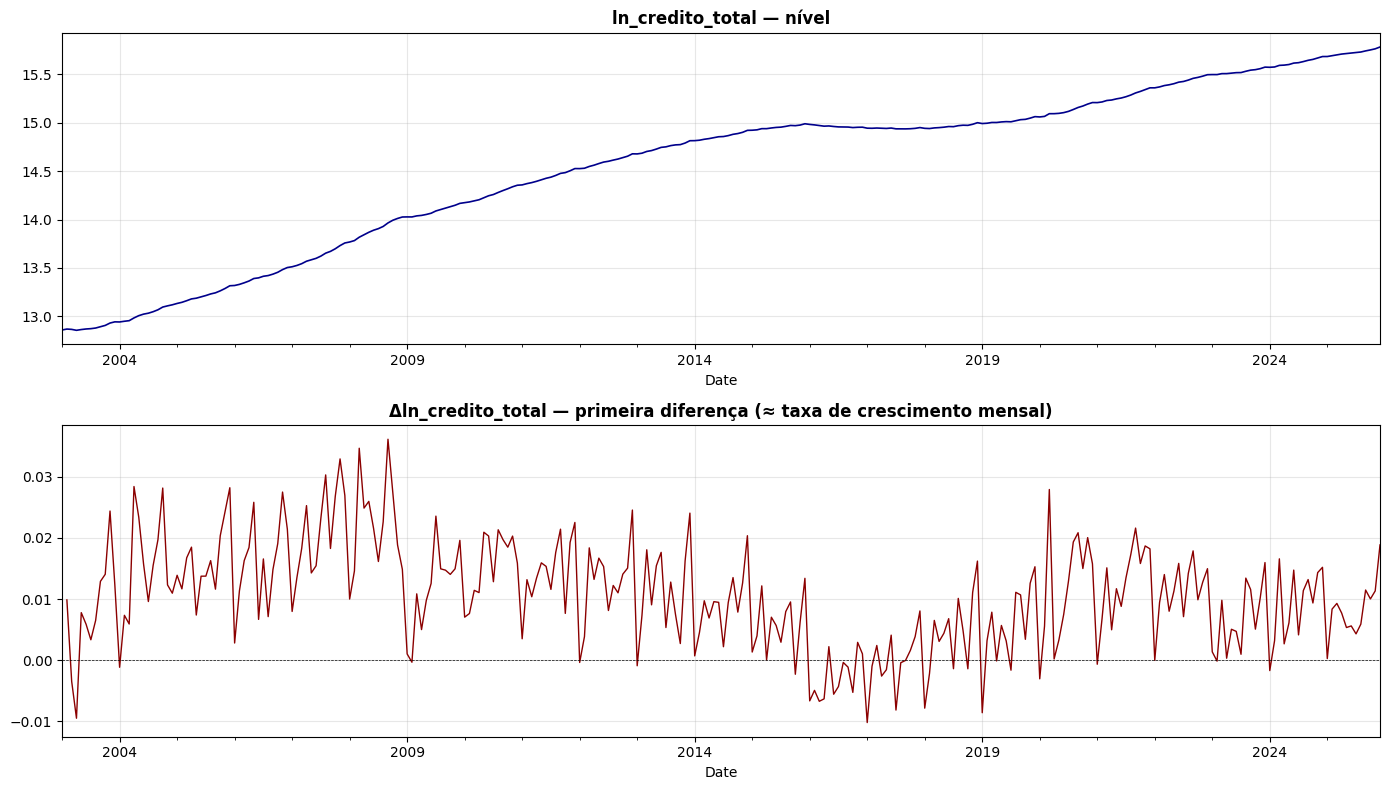

In [12]:
# Visualiza a primeira diferença do crédito para diagnóstico
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Série em nível
df['ln_credito_total'].plot(ax=axes[0], color='darkblue', linewidth=1.2)
axes[0].set_title('ln_credito_total — nível', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Primeira diferença
df['ln_credito_total'].diff().plot(ax=axes[1], color='darkred', linewidth=1)
axes[1].axhline(y=0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title('Δln_credito_total — primeira diferença (≈ taxa de crescimento mensal)', 
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2 Diagnóstico da visualização

A primeira diferença de `ln_credito_total` revela **três regimes distintos** 
na taxa de crescimento mensal:

| Período | Taxa média estimada | Contexto econômico |
|---------|:-------------------:|--------------------|
| 2003-2009 | ~1.5-2.0% | Boom do consignado, expansão do BNDES |
| 2010-2014 | ~1.0% | Saturação, início da crise Dilma 1 |
| 2015-2018 | próximo a 0% | Recessão 2015-16, estagnação severa |
| 2019-2025 | ~1.0% | Recuperação parcial pós-Temer |

A série oscila em torno de patamares positivos em todos os regimes — não 
exibe comportamento de raiz unitária. A divergência ADF/PP é portanto um 
**diagnóstico de mudança de regime na taxa de crescimento**, não evidência 
de I(2).

#### Decisão final

`ln_credito_total` é classificada como **I(1)**, consistente com a evidência 
do teste PP (p=0.0000) e com a inspeção visual. A mudança de regime mais 
expressiva (queda brusca em 2015) será capturada via dummy de quebra 
estrutural no Bloco 5.

### 3.3 Tabela consolidada — ordem de integração final

| Série | Decisão final |
|-------|:-------------:|
| `ln_ibcbr` | I(1) |
| `ln_cambio` | I(1) |
| `ln_commodities` | I(1) |
| `ln_m1` | I(1) |
| `ln_prod_industrial` | I(1) com dummy de quebra |
| `ln_credito_total` | I(1) com dummy de quebra |
| `ipca` | **I(0)** |
| `selic` | I(1) com dummy de quebra |
| `exp_ipca_12m` | I(1) |

Das 9 séries, **8 são I(1) e 1 é I(0) (`ipca`)**. Três séries necessitam 
dummies adicionais de quebra estrutural a serem incluídas no Bloco 5.

## 4. Testes de cointegração

### Motivação

Com 8 séries identificadas como I(1) e 1 como I(0), a decisão de especificação 
do modelo final (VAR em diferenças vs. VECM) depende de **existir cointegração** 
entre subconjuntos das séries I(1). 

Cointegração significa que, embora as séries sejam individualmente 
não-estacionárias, existe combinação linear delas que é estacionária — uma 
**relação de equilíbrio de longo prazo** entre as variáveis. Quando isso 
ocorre, diferenciar todas as séries e estimar VAR em diferenças destrói essa 
informação. A especificação correta é VECM, que decompõe o modelo em duas 
partes: dinâmica de curto prazo (em diferenças) e correção em direção ao 
equilíbrio de longo prazo (em níveis).

### Estratégia adotada

Em vez de aplicar Johansen sobre todas as 9 variáveis simultaneamente (frágil 
estatisticamente e difícil de interpretar com tantas variáveis), iremos testar 
**quatro hipóteses teóricas específicas**, sendo elas:

| Grupo | Variáveis | Hipótese econômica |
|-------|-----------|--------------------|
| 1 | `ln_m1`, `ln_ibcbr`, `selic` | Demanda por moeda (Cagan/Friedman) |
| 2 | `ln_commodities`, `ln_cambio` | Commodity currency (Chen-Rogoff) |
| 3 | `ln_credito_total`, `ln_ibcbr` | Aprofundamento financeiro |
| 4 | `selic`, `exp_ipca_12m` | Fisher relativo (juros nominal = juros real + expectativa) |

### Dois testes complementares

Aplicaremos dois testes em cada grupo:

**Engle-Granger:** teste em dois estágios, mais simples e adequado para 
verificar **uma única relação de cointegração** entre poucas variáveis. 
Suposição: uma das variáveis é claramente a "dependente" (variável que ajusta 
em direção ao equilíbrio).

**Johansen:** teste baseado em sistema, identifica **quantas relações** de 
cointegração existem (até $n-1$ em um sistema de $n$ variáveis I(1)). Mais 
robusto para grupos com 3 ou mais variáveis. Não exige especificar variável 
dependente.

Aplicaremos **ambos os testes em todos os grupos**, comparando resultados.

In [13]:
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen, select_coint_rank

def teste_engle_granger(y, x, nome_y, nome_x):
    """
    Aplica Engle-Granger em duas etapas, testando cointegração entre y e x.
    
    Roda nas duas direções (y~x e x~y) e reporta o resultado mais conservador.
    
    Parameters
    ----------
    y, x : pd.Series
        Séries a testar (já limpas, sem NaN)
    nome_y, nome_x : str
        Nomes para identificação
    
    Returns
    -------
    dict com estatística t, p-valor, número de defasagens
    """
    # Direção 1: y como dependente
    stat1, pvalue1, _ = coint(y, x, trend='c', autolag='AIC')
    
    # Direção 2: x como dependente
    stat2, pvalue2, _ = coint(x, y, trend='c', autolag='AIC')
    
    return {
        'grupo': f'{nome_y} ~ {nome_x}',
        'eg_stat_y_sobre_x': stat1,
        'eg_pvalue_y_sobre_x': pvalue1,
        'eg_stat_x_sobre_y': stat2,
        'eg_pvalue_x_sobre_y': pvalue2,
        'rejeita_5pct': (pvalue1 < 0.05) or (pvalue2 < 0.05),
    }

In [14]:
def teste_johansen(df_grupo, nome_grupo, det_order=0, k_ar_diff=1):
    """
    Aplica teste de Johansen para encontrar o número de relações de cointegração.
    
    Parameters
    ----------
    df_grupo : pd.DataFrame
        DataFrame com as séries a testar (uma por coluna)
    nome_grupo : str
        Identificador
    det_order : int
        -1: sem termo determinístico
         0: constante no espaço de cointegração (Caso 2)
         1: constante irrestrita (Caso 3) — DEFAULT
    k_ar_diff : int
        Número de defasagens em diferenças no VECM
    
    Returns
    -------
    dict com resultados de trace test e max eigenvalue test
    """
    df_limpo = df_grupo.dropna()
    
    resultado = coint_johansen(df_limpo, det_order=det_order, k_ar_diff=k_ar_diff)
    
    n = df_limpo.shape[1]
    
    # Para cada possível r (0, 1, ..., n-1), compara estatística com valor crítico
    trace_stats = resultado.lr1
    trace_crit_5pct = resultado.cvt[:, 1]  # coluna 1 = 5%
    
    max_stats = resultado.lr2
    max_crit_5pct = resultado.cvm[:, 1]
    
    # Determina rank pelo trace test
    r_trace = 0
    for i in range(n):
        if trace_stats[i] > trace_crit_5pct[i]:
            r_trace = i + 1
        else:
            break
    
    r_max = 0
    for i in range(n):
        if max_stats[i] > max_crit_5pct[i]:
            r_max = i + 1
        else:
            break
    
    return {
        'grupo': nome_grupo,
        'n_variaveis': n,
        'trace_stats': trace_stats,
        'trace_crit_5pct': trace_crit_5pct,
        'max_stats': max_stats,
        'max_crit_5pct': max_crit_5pct,
        'r_trace': r_trace,
        'r_max': r_max,
    }


def imprimir_johansen(res):
    """Formata e imprime o resultado de Johansen."""
    print(f"\nGrupo: {res['grupo']}")
    print(f"Variáveis no sistema: {res['n_variaveis']}")
    print(f"\n  Trace test:")
    for i, (stat, crit) in enumerate(zip(res['trace_stats'], res['trace_crit_5pct'])):
        rejeita = '✓' if stat > crit else '✗'
        print(f"    H₀: r ≤ {i}    stat={stat:>8.3f}    crit 5%={crit:>8.3f}    {rejeita}")
    print(f"\n  Max eigenvalue test:")
    for i, (stat, crit) in enumerate(zip(res['max_stats'], res['max_crit_5pct'])):
        rejeita = '✓' if stat > crit else '✗'
        print(f"    H₀: r = {i}    stat={stat:>8.3f}    crit 5%={crit:>8.3f}    {rejeita}")
    print(f"\n  Conclusão:")
    print(f"    Trace test       → r = {res['r_trace']}")
    print(f"    Max eigenvalue   → r = {res['r_max']}")

In [15]:
# Define os grupos de hipóteses
grupos = {
    'Grupo 1 — Demanda por moeda': ['ln_m1', 'ln_ibcbr', 'selic'],
    'Grupo 2 — Commodity currency': ['ln_commodities', 'ln_cambio'],
    'Grupo 3 — Aprofundamento financeiro': ['ln_credito_total', 'ln_ibcbr'],
    'Grupo 4 — Fisher relativo': ['selic', 'exp_ipca_12m'],
}

print("=" * 80)
print("TESTES DE COINTEGRAÇÃO")
print("=" * 80)

resultados_cointegracao = []

for nome_grupo, variaveis in grupos.items():
    print(f"\n{'─' * 80}")
    print(f"{nome_grupo}")
    print(f"Variáveis: {variaveis}")
    print(f"{'─' * 80}")
    
    df_grupo = df[variaveis]
    
    # Engle-Granger (bivariado): aplicável apenas a grupos com 2 variáveis
    if len(variaveis) == 2:
        y_serie = df_grupo[variaveis[0]].dropna()
        x_serie = df_grupo[variaveis[1]].dropna()
        eg = teste_engle_granger(y_serie, x_serie, variaveis[0], variaveis[1])
        print(f"\nEngle-Granger:")
        print(f"  {variaveis[0]} ~ {variaveis[1]}: stat={eg['eg_stat_y_sobre_x']:>7.3f}, p-valor={eg['eg_pvalue_y_sobre_x']:.4f}")
        print(f"  {variaveis[1]} ~ {variaveis[0]}: stat={eg['eg_stat_x_sobre_y']:>7.3f}, p-valor={eg['eg_pvalue_x_sobre_y']:.4f}")
        print(f"  → Cointegração detectada (5%): {eg['rejeita_5pct']}")
    
    # Johansen: aplicável a 2 ou mais variáveis
    joh = teste_johansen(df_grupo, nome_grupo, det_order=0, k_ar_diff=1)
    imprimir_johansen(joh)
    
    resultados_cointegracao.append({
        'grupo': nome_grupo,
        'variaveis': variaveis,
        'r_trace': joh['r_trace'],
        'r_max': joh['r_max'],
    })

TESTES DE COINTEGRAÇÃO

────────────────────────────────────────────────────────────────────────────────
Grupo 1 — Demanda por moeda
Variáveis: ['ln_m1', 'ln_ibcbr', 'selic']
────────────────────────────────────────────────────────────────────────────────

Grupo: Grupo 1 — Demanda por moeda
Variáveis no sistema: 3

  Trace test:
    H₀: r ≤ 0    stat=  56.265    crit 5%=  29.796    ✓
    H₀: r ≤ 1    stat=  17.191    crit 5%=  15.494    ✓
    H₀: r ≤ 2    stat=   3.222    crit 5%=   3.841    ✗

  Max eigenvalue test:
    H₀: r = 0    stat=  39.074    crit 5%=  21.131    ✓
    H₀: r = 1    stat=  13.969    crit 5%=  14.264    ✗
    H₀: r = 2    stat=   3.222    crit 5%=   3.841    ✗

  Conclusão:
    Trace test       → r = 2
    Max eigenvalue   → r = 1

────────────────────────────────────────────────────────────────────────────────
Grupo 2 — Commodity currency
Variáveis: ['ln_commodities', 'ln_cambio']
────────────────────────────────────────────────────────────────────────────────

E

### 4.1 Interpretação consolidada dos resultados

#### Síntese tabular

| Grupo | Engle-Granger | Johansen Trace | Johansen Max | Conclusão |
|-------|:-------------:|:--------------:|:------------:|:---------:|
| 1 — Demanda por moeda (M1, IBC-Br, Selic) | n/a (3 var.) | $r=2$ | $r=1$ | **$r=1$** |
| 2 — Commodity currency (commodities, câmbio) | Sem | $r=0$ | $r=0$ | **Sem cointegração** |
| 3 — Aprofundamento financeiro (crédito, IBC-Br) | Sem | $r=2$ (espúrio) | $r=2$ (espúrio) | **Sem cointegração** |
| 4 — Fisher relativo (Selic, expectativa) | Sem | $r=2$ (espúrio) | $r=2$ (espúrio) | **Sem cointegração** |

#### Análise grupo a grupo

**Grupo 1 — Demanda por moeda (M1, IBC-Br, Selic).** O trace test sugere $r=2$ 
mas o max eigenvalue test sugere $r=1$, com a estatística de $H_0: r=1$ ficando 
abaixo do valor crítico por margem mínima. Em prática aplicada, o max eigenvalue 
é mais conservador e robusto quando o trace exagera. Adotamos $r=1$, consistente 
com a teoria de demanda por moeda (Cagan/Friedman): uma única relação de 
equilíbrio de longo prazo entre o estoque real de moeda, atividade econômica 
e custo de oportunidade. Esta é a **única evidência robusta de cointegração** 
nos quatro grupos testados.

**Grupo 2 — Commodity currency (commodities, câmbio).** Os três testes 
(Engle-Granger nas duas direções, Johansen trace, Johansen max) concordam 
em **não rejeitar a hipótese de ausência de cointegração**. O resultado 
contraria a hipótese tradicional de Chen-Rogoff e a evidência brasileira 
do início dos anos 2000, mas é consistente com a literatura recente 
(pós-2015), que documenta enfraquecimento da relação commodity-câmbio no 
Brasil após o fim do superciclo de commodities. Após 2014-2015, o câmbio 
brasileiro passou a refletir mais fortemente fatores fiscais, políticos e 
de risco-país, "descolando" parcialmente da dinâmica de preços de commodities.

**Grupo 3 — Aprofundamento financeiro (crédito, IBC-Br).** Resultado 
**contraditório**: Engle-Granger fortemente não rejeita cointegração em ambas 
as direções (p-valores 0.27 e 0.50), enquanto Johansen sugere $r=2$. Como o 
sistema tem apenas 2 variáveis, $r=2$ implicaria que todas as séries são 
$I(0)$ — contradição direta com nossa classificação anterior de ambas as 
séries como $I(1)$. O resultado do Johansen é, portanto, **espúrio**, 
provavelmente induzido por:

- Quebra estrutural não-modelada no crédito (mudança brusca de regime na 
  taxa de crescimento em 2015-2018, identificada na Etapa 3)
- Divergência ADF/PP no crédito sugerindo comportamento não-clássico das 
  séries
- Johansen assume estabilidade da relação ao longo do tempo, premissa 
  violada quando há mudança de regime

Conclusão: **adotamos não cointegração** entre crédito e IBC-Br, baseado 
no Engle-Granger e na inconsistência lógica do resultado do Johansen. 
Economicamente plausível dado o trauma de 2015-2018 no mercado de crédito 
brasileiro.

**Grupo 4 — Fisher relativo (Selic, expectativa de inflação).** Mesmo 
padrão do Grupo 3: Engle-Granger não rejeita ausência de cointegração 
(p-valores 0.57 e 0.69), Johansen sugere $r=2$ espúrio. Possíveis razões:

- A `exp_ipca_12m` tem evidência mista de ordem de integração 
  (ADF/KPSS sugerem $I(1)$, PP sugere $I(0)$). Se for $I(0)$, sua 
  inclusão no Johansen com Selic $I(1)$ invalida o teste.
- Quebras estruturais não-modeladas em ambas as séries (regime monetário 
  variável na Selic, desancoragem pós-2021 nas expectativas).
- A hipótese de Fisher relativo no Brasil pode ter enfraquecido após a 
  desancoragem das expectativas em 2021-2022.

Conclusão: **adotamos não cointegração** entre Selic e expectativa de 
inflação no período estudado, baseado no Engle-Granger.

#### Regra de bom-senso aplicada

Quando Engle-Granger e Johansen divergem frontalmente, e o resultado do 
Johansen é estatisticamente impossível (rank maior que o número de variáveis 
$I(1)$ no sistema), prevalece a evidência consensual via Engle-Granger. 
**Esta divergência é, ela mesma, evidência de má especificação** — 
tipicamente quebras estruturais não-modeladas, mais do que evidência real 
de cointegração ausente.

### 4.2 Implicação para a especificação do modelo

Apenas o Grupo 1 apresenta evidência robusta de cointegração. Três caminhos 
de modelagem ficam abertos:

- **Caminho A** — VECM apenas para o Grupo 1, VAR em diferenças para o 
  resto. Implementação complexa, risco de inconsistências.
- **Caminho B** — VAR em diferenças para todas as séries $I(1)$, IPCA em 
  nível. Simples, robusto, perde apenas uma relação de longo prazo.
- **Caminho C** — Johansen com o sistema completo (todas as 8 séries $I(1)$ 
  simultaneamente). Mais rigoroso estatisticamente, pode revelar relações 
  não capturadas nos testes em subgrupos.

**Procedimento adotado:** testar primeiro o Caminho C; se o resultado for 
robusto e interpretável, seguir com VECM; caso contrário, adotar Caminho B 
(VAR em diferenças).

## 5. Johansen no sistema completo (Caminho C)

### Procedimento

Os testes bivariados/trivariados anteriores (4 grupos com 2-3 variáveis) podem 
não capturar relações de cointegração que envolvem mais variáveis simultaneamente. 
Por exemplo, pode existir uma relação macro envolvendo IBC-Br, Selic, câmbio e 
expectativa que não aparece em nenhum subgrupo de 2-3 variáveis.

Para verificar essa possibilidade, aplicamos o **teste de Johansen no sistema 
completo**, incluindo todas as séries identificadas como I(1):

- `ln_ibcbr`, `ln_cambio`, `ln_commodities`, `ln_m1`, `ln_prod_industrial`, 
  `ln_credito_total`, `selic`, `exp_ipca_12m`

O IPCA é excluído por ser I(0): Johansen exige que todas as séries do sistema 
tenham a mesma ordem de integração.

### Cuidados de interpretação

Sistemas Johansen grandes têm problemas conhecidos:

1. **Poder estatístico reduzido:** com 8 variáveis e ~275 observações, a 
   estatística do teste pode ser inflada artificialmente, sugerindo mais 
   relações de cointegração do que economicamente plausível.

2. **Sensibilidade à especificação:** escolha de lags, termo determinístico 
   e quebras estruturais não-modeladas afetam fortemente o resultado.

3. **Interpretação econômica:** mesmo se o teste indicar $r \geq 2$, 
   interpretar múltiplas relações de cointegração em sistema grande é difícil 
   e frágil.

Por essas razões, tratamos o resultado deste teste como **diagnóstico**, não 
como decisão automática. Cruzamos com a interpretação econômica e com os 
testes bivariados/trivariados já feitos.

In [16]:
# Sistema completo (todas as séries I(1))
series_i1_completo = [
    'ln_ibcbr', 'ln_cambio', 'ln_commodities', 'ln_m1',
    'ln_prod_industrial', 'ln_credito_total', 'selic', 'exp_ipca_12m'
]

df_sistema = df[series_i1_completo]

print("=" * 80)
print("JOHANSEN — SISTEMA COMPLETO (8 séries I(1))")
print("=" * 80)
print(f"\nVariáveis: {series_i1_completo}")
print(f"Observações: {len(df_sistema)}")

# Aplica Johansen com Caso 3 (det_order=0): constante restrita
joh_sistema = teste_johansen(df_sistema, 'Sistema completo', det_order=0, k_ar_diff=1)
imprimir_johansen(joh_sistema)

JOHANSEN — SISTEMA COMPLETO (8 séries I(1))

Variáveis: ['ln_ibcbr', 'ln_cambio', 'ln_commodities', 'ln_m1', 'ln_prod_industrial', 'ln_credito_total', 'selic', 'exp_ipca_12m']
Observações: 276

Grupo: Sistema completo
Variáveis no sistema: 8

  Trace test:
    H₀: r ≤ 0    stat= 383.831    crit 5%= 159.529    ✓
    H₀: r ≤ 1    stat= 253.981    crit 5%= 125.618    ✓
    H₀: r ≤ 2    stat= 151.851    crit 5%=  95.754    ✓
    H₀: r ≤ 3    stat=  96.580    crit 5%=  69.819    ✓
    H₀: r ≤ 4    stat=  59.424    crit 5%=  47.855    ✓
    H₀: r ≤ 5    stat=  32.472    crit 5%=  29.796    ✓
    H₀: r ≤ 6    stat=  13.729    crit 5%=  15.494    ✗
    H₀: r ≤ 7    stat=   0.911    crit 5%=   3.841    ✗

  Max eigenvalue test:
    H₀: r = 0    stat= 129.850    crit 5%=  52.362    ✓
    H₀: r = 1    stat= 102.130    crit 5%=  46.230    ✓
    H₀: r = 2    stat=  55.271    crit 5%=  40.076    ✓
    H₀: r = 3    stat=  37.156    crit 5%=  33.878    ✓
    H₀: r = 4    stat=  26.952    crit 5%=  27.

### 5.1 Interpretação do Johansen no sistema completo

O teste sugeriu $r = 6$ (trace) e $r = 4$ (max eigenvalue), valores 
economicamente implausíveis. Quatro hipóteses explicam esses resultados 
espúrios:

**1. Quebras estruturais não-modeladas.** Câmbio (2014-2015), produção 
industrial (2014-2015), crédito (2015-2018) e Selic (regime variável) 
têm quebras visualmente claras. Johansen assume estabilidade dos 
parâmetros; quebras geram resíduos sistemáticos interpretados como 
relações de cointegração adicionais.

**2. Distorção de tamanho em amostras finitas.** Reinsel & Ahn (1992) 
mostraram que Johansen superestima $r$ em sistemas grandes com amostras 
relativamente pequenas. Para 8 variáveis, recomenda-se 
$T \geq 240$ — estamos no limite (T=276), e o teste tende a inflar $r$.

**3. Heteroscedasticidade.** Volatilidade variável no tempo (calmaria 
2004-2008 vs. turbulência 2002-2003, 2015-2016, 2020) viola hipótese 
de homocedasticidade do teste.

**4. Cointegração genuína mas não-interpretável.** Tecnicamente possível 
mas improvável, dado o conflito com os testes em subgrupos.

**Diagnóstico:** combinação de (1), (2) e (3), com (4) descartado pela 
inconsistência com os testes em subgrupos. O resultado é tratado como 
**não-informativo** sobre a verdadeira estrutura de cointegração do 
sistema.

## 6. Decisão final de especificação

Sintetizando todas as evidências do Bloco 4:

| Aspecto | Evidência |
|---------|-----------|
| Ordem de integração das séries | 8 séries I(1), 1 série I(0) (IPCA) |
| Cointegração — testes bivariados/trivariados | 3 dos 4 grupos sem cointegração; Grupo 1 com $r=1$ fronteiriço |
| Cointegração — sistema completo | Resultado espúrio, não-informativo |
| Quebras estruturais | Identificadas em câmbio, indústria, crédito, Selic |

**Especificação adotada:** **VAR em diferenças** (Caminho B), com as 
seguintes características:

- Todas as séries I(1) entram em **primeira diferença** ($\Delta \ln$ ou 
  $\Delta$)
- IPCA entra em **nível** (I(0))
- **Dummies de pandemia** como variáveis exógenas (mar-set 2020, já criadas)
- **Dummies de quebra estrutural** como variáveis exógenas:
  - Selic: 2017-01 em diante
  - `ln_cambio`: 2014-09 em diante
  - `ln_prod_industrial`: 2014-09 em diante
  - `ln_credito_total`: 2015-01 em diante

### Trade-offs assumidos

**Perda:** abdicamos de modelar explicitamente a possível relação de 
cointegração do Grupo 1 (demanda por moeda). Esta perda é defensável: 
a evidência era fronteiriça (max eigenvalue rejeitou H₀ por margem 
mínima), e modelar VECM apenas para um subsistema causaria 
inconsistências.

**Ganho:** especificação mais robusta a quebras estruturais, mais simples 
de interpretar, e amplamente aceita na literatura brasileira aplicada.

### O que o Bloco 5 vai fazer

Com as séries pronts e a especificação decidida, o próximo bloco implementa:

1. Construção do conjunto final de variáveis (diferenças onde aplicável)
2. Construção das dummies de quebra estrutural
3. Seleção de defasagens do VAR via critérios de informação
4. Estimação do VAR baseline
5. Diagnósticos de resíduos
6. IRFs com identificação de Cholesky
7. Decomposição da variância (FEVD)
8. Comparação direta com os resultados da monografia